<a href="https://colab.research.google.com/github/raheelam98/DataAnalysis/blob/main/EDA/EDA_Sessions_RM/DA5_Missing_values_and_outliers_Sec_3_RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data loading

#### Subtask:
Load the data from the provided CSV file into a pandas DataFrame.


Reasoning: Load the data from the provided CSV file into a pandas DataFrame and display the first few rows.

In [41]:
import pandas as pd

df = pd.read_csv('/content/sample_data/EDA/bus_fare_dataset.csv')

display(df.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Data exploration

#### Subtask:
Explore the loaded data to understand its structure and basic statistics.


## Data exploration

### Subtask:
Explore the loaded data to understand its structure and basic statistics.


In [42]:
# Check dimensions
print("Shape of the DataFrame:\n", df.shape)

# Examine data types
print("\n\nData types of each column:\n")
print(df.info())

# Descriptive statistics for numerical columns
print("\n\nDescriptive statistics for numerical columns:\n")
print(df.describe())

# Display first few rows
print("\n\nFirst few rows of the DataFrame:\n")
display(df.head())


Shape of the DataFrame:
 (418, 11)


Data types of each column:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


Descriptive statistics for numerical columns:

       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   418.000000  418.000000  332.000000  418.000000  418.000000  417.000000
mean   11

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [43]:
# Unique values in categorical columns
print("\nUnique values in categorical columns:")
for col in ['Sex', 'Embarked']:  # Example categorical columns
    print(f"\nColumn '{col}':")
    print(df[col].unique())
    print(df[col].value_counts())


Unique values in categorical columns:

Column 'Sex':
['male' 'female']
Sex
male      266
female    152
Name: count, dtype: int64

Column 'Embarked':
['Q' 'S' 'C']
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64


In [21]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**RM Notes**

## **Unique Values**

### **Number of Unique Values in the specified column**

**`df['ColumnName'].nunique()`**

Returns the **number of unique values in the specified column** of a Pandas DataFrame.

**Use When:**

- You want to know how many distinct categories or values a column contains.
- It’s useful for categorical variables, especially during feature engineering (e.g., before encoding).


### **Count of Each Unique Value in a Series (column)**

**`df['ColumnName'].value_counts()`**

Returns a **count of each unique value in a Series (column)**, sorted in descending order by default.

**Use When:**

- You want to see how often each value occurs.
- Ideal for exploring data distribution and identifying common or rare categories.


In [22]:
# Return a Series containing counts of unique values.
df['Sex'].value_counts()

,count
Sex,
male,266
female,152


In [26]:
# Return a Series containing counts of unique values.
df['Cabin'].value_counts()

,count
Cabin,
B57 B59 B63 B66,3
B45,2
C23 C25 C27,2
C78,2
C31,2
...,...
B41,1
C7,1
D40,1


In [28]:
df['SibSp'].value_counts()

,count
SibSp,
0,283
1,110
2,14
3,4
4,4
8,2
5,1


In [29]:
df['Parch'].value_counts()

,count
Parch,
0,324
1,52
2,33
3,3
4,2
9,2
6,1
5,1


In [30]:
df['Parch'].unique()

array([0, 1, 3, 2, 4, 6, 5, 9])

In [32]:
# Returns the number of unique values in the column of a DataFrame
df['Parch'].nunique()

8

In [35]:
for col in df.columns:  # Example categorical columns
    print(f"\nColumn '{col}':")
    print("nunique :",df[col].nunique())
    print("value_counts :",df[col].value_counts())
    print("---------------------------------------------\n")


Column 'PassengerId':
nunique : 418
value_counts : PassengerId
1309    1
892     1
1293    1
1292    1
1291    1
       ..
898     1
897     1
896     1
895     1
894     1
Name: count, Length: 418, dtype: int64
---------------------------------------------


Column 'Pclass':
nunique : 3
value_counts : Pclass
3    218
1    107
2     93
Name: count, dtype: int64
---------------------------------------------


Column 'Name':
nunique : 418
value_counts : Name
Peter, Master. Michael J                        1
Kelly, Mr. James                                1
Gale, Mr. Harry                                 1
Bonnell, Miss. Caroline                         1
Conlon, Mr. Thomas Henry                        1
                                               ..
Connolly, Miss. Kate                            1
Svensson, Mr. Johan Cervin                      1
Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1
Wirz, Mr. Albert                                1
Myles, Mr. Thomas Francis             

**RM Notes**

### **Count missing values in each column :**

**` df.isnull().sum() `**

**Explanation**

**` df.isnull() `** Returns a DataFrame of the same shape as df, where each cell is:

- True if the value is missing (NaN)
- False if the value is present


In [44]:
#age fare and cabin -- missing values in each column
df.isnull().sum()
#age % missing value-- no of missing value/ total data *100

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [46]:
#% of missing values in a column
missing_values = df.isnull().sum() # how many missing values in the column

missing_percentage = (missing_values / len(df)) * 100 # len----> no of rows

print("\nMissing Value Percentage:\n\n", missing_percentage)

## % missing value-- no of missing value/ total data *100


Missing Value Percentage:

 PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


**RM Notes**

### **Histogram**

A **histogram displays** the distribution of a single numeric variable by showing the **frequency of values within continuous intervals** (bins).

- Single numerical variable: Yes — histograms are for one continuous variable.

- Frequency: Yes — it shows how often values occur within each interval.

- Continuous intervals (bins): Yes — the x-axis is split into equal-width ranges.



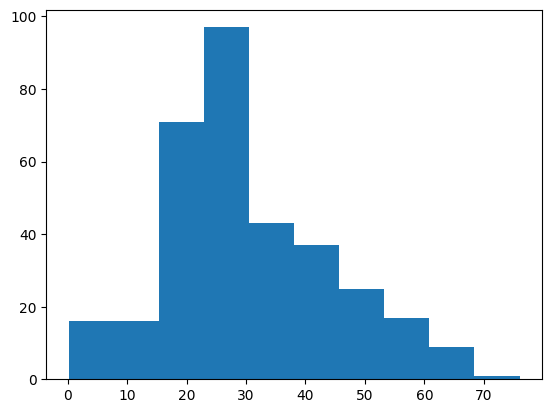

In [47]:
#fare and age imputation--- continous --- shape of the column
#histogram making
import matplotlib.pyplot as plt

plt.hist(df["Age"])
plt.show() # plot to show


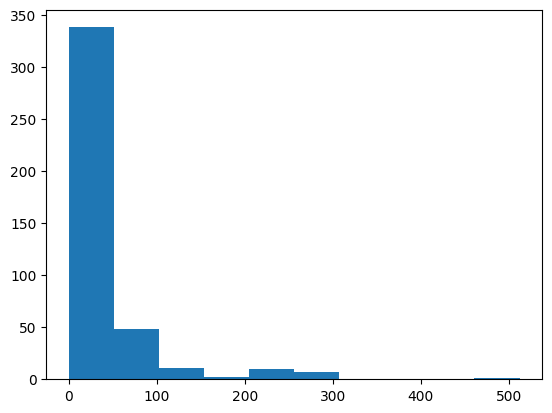

In [48]:
#fare and age imputation--- continous --- shape of the column
#histogram making

import matplotlib.pyplot as plt

plt.hist(df['Fare'])
plt.show()

#skewd--- median

### **Descriptive Statistics :  Mean - Median - Mode**

- **Mean**: Average of all values  
- **Median**: Middle value of ordered data  
- **Mode**: Most frequent value in the dataset


**` df['column_name'].mean() `**

**` df['column_name'].median() `**

**` df['column_name'].mode() `**


In [49]:
# The mode is the value that appears most often. There can be multiple modes.
# Always returns Series even if only one value is returned.
df['Fare'].mode()

,Fare
0,7.75


In [50]:
df['Fare'].median()

14.4542

In [51]:
df['Fare'].value_counts()

,count
Fare,
7.7500,21
26.0000,19
8.0500,17
13.0000,17
7.8958,11
...,...
13.8625,1
7.7208,1
90.0000,1


In [ ]:
# cabinet --- delete
# age-- median -- outlier
# fare-- mode --

### Data analysis

#### Subtask:
Analyze the data for missing values and potential outliers.


**Reasoning**:
Calculate the number and percentage of missing values, detect outliers in numerical columns using IQR, and examine categorical columns for unusual values.


Text(0.5, 1.0, 'Box Plot of Age')

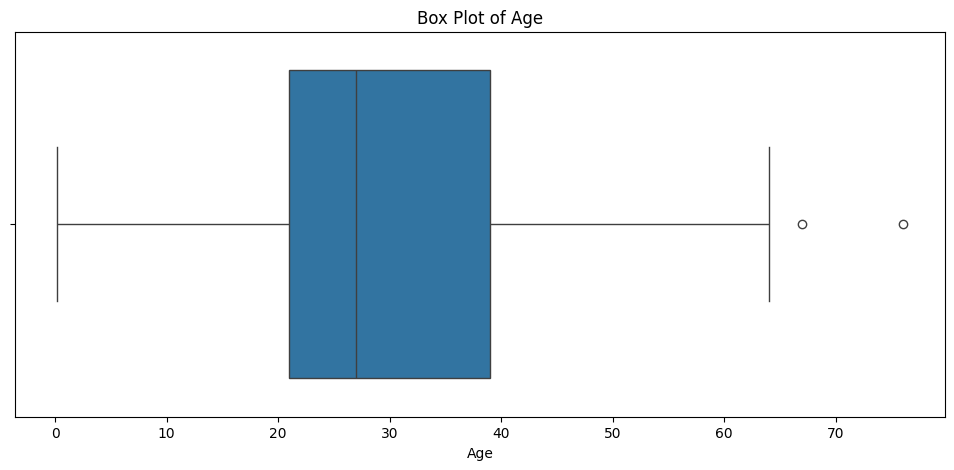

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
# Box plots for 'Age' and 'Fare'
plt.figure(figsize=(12,5))

sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')


**RM Notes**

### **IQR (Interquartile Range)**

**IQR (Interquartile Range)** is a measure of statistical dispersion — it tells you how spread out the middle 50% of your data is.

**` Q1 = df['column_name'].quantile(0.25) `** returns the value at a given percentile of a numeric Series or column.

Calculate the Interquartile Range (IQR)

**` IQR = Q3 - Q1 `**

- **Q1** = 1st Quartile = 25th percentile — value below which 25% of the data falls  
- **Q3** = 3rd Quartile = 75th percentile — value below which 75% of the data falls

**Key Points :**

- IQR focuses on the **middle 50%** of your data (between Q1 and Q3)  
- It **ignores extreme values** (the lowest 25% and highest 25%)  
- A **larger IQR** means your data is more spread out  
- A **smaller IQR** means your data is more concentrated  

**Define the Bounds**

- **` Lower Bound = Q1 - 1.5 × IQR `**
- **` Upper Bound = Q3 + 1.5 × IQR `**

**Identify Outliers**

**` outliers = df['column_name'][(df['column_name'] < lower_bound) | (df['column_name'] > upper_bound)]  `**




In [55]:
# function to detect outliers using the IQR (Interquartile Range) method:

def detect_outliers_iqr(data):

    # Calculate the first quartile (25th percentile)
    Q1 = data.quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = data.quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1  # This represents the range of the middle 50% of the data

    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR  # Anything below this is considered an outlier
    upper_bound = Q3 + 1.5 * IQR  # Anything above this is considered an outlier

    # Identify the outliers using the IQR rule
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return outliers

# Call the function on the 'Age' column of the DataFrame
age_outliers = detect_outliers_iqr(df['Age'])

# Print the outliers found in the 'Age' column
print("\nAge Outliers:\n", age_outliers)



Age Outliers:
 81    67.0
96    76.0
Name: Age, dtype: float64


In [56]:
df[df['Age'] >= 67]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
81,973,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
96,988,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S


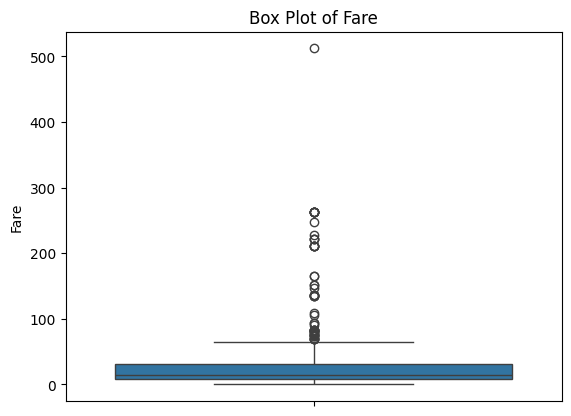

In [57]:

sns.boxplot(y=df['Fare']) # vertical orientation

plt.title('Box Plot of Fare')
plt.show()

In [58]:
df[df['Fare']> 500]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
343,1235,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C


In [59]:
# calling function

fare_outliers = detect_outliers_iqr(df['Fare'])

print('\nFare Outliers :\n', fare_outliers)


Fare Outliers :
 12      82.2667
24     262.3750
48      76.2917
53     263.0000
59     262.3750
64     262.3750
69     263.0000
74     211.5000
75     211.5000
81     221.7792
96      78.8500
114    221.7792
118     75.2417
141    151.5500
142    262.3750
150     83.1583
156    221.7792
179     83.1583
181     83.1583
184    247.5208
188     69.5500
196    134.5000
202    227.5250
212     73.5000
217    164.8667
218    211.5000
234     71.2833
236     75.2500
239    106.4250
242    134.5000
252    136.7792
270     75.2417
272    136.7792
287     82.2667
293     81.8583
306    151.5500
308     93.5000
314    135.6333
316    146.5208
324    211.3375
327     79.2000
342     69.5500
343    512.3292
352     73.5000
360     69.5500
365     69.5500
371    134.5000
374     81.8583
375    262.3750
390     93.5000
397     79.2000
400    164.8667
407    211.5000
411     90.0000
414    108.9000
Name: Fare, dtype: float64


In [62]:
# Missing Value Analysis
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print("Missing Values:\n", missing_values)
print("\n\nMissing Value Percentage:\n", missing_percentage)

# Outlier Detection (IQR for 'Age' and 'Fare')
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

age_outliers = detect_outliers_iqr(df['Age'])
fare_outliers = detect_outliers_iqr(df['Fare'])

print("\n\nAge Outliers:\n", age_outliers)
print("\n\nFare Outliers:\n", fare_outliers)

Missing Values:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


Missing Value Percentage:
 PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


Age Outliers:
 81    67.0
96    76.0
Name: Age, dtype: float64


Fare Outliers:
 12      82.2667
24     262.3750
48      76.2917
53     263.0000
59     262.3750
64     262.3750
69     263.0000
74     211.5000
75     211.5000
81     221.7792
96      78.8500
114    221.7792
118     75.2417
141    151.5500
142    262.3750
150     83.1583
156    221.7792
179     83.1583
181     83.1583
184    247.5208
188     69.5500
196    134.5000
202    

In [64]:
# Categorical Column Analysis
for col in ['Embarked', 'Sex', 'Pclass']:
    print(f"\nUnique values in column '{col}':")
    print('unique :',df[col].unique())
    print('value_counts :',df[col].value_counts())


Unique values in column 'Embarked':
unique : ['Q' 'S' 'C']
value_counts : Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

Unique values in column 'Sex':
unique : ['male' 'female']
value_counts : Sex
male      266
female    152
Name: count, dtype: int64

Unique values in column 'Pclass':
unique : [3 2 1]
value_counts : Pclass
3    218
1    107
2     93
Name: count, dtype: int64


## Data visualization

#### Subtask:
Visualize the distribution of data and identify outliers using histograms and box plots.


**Reasoning**:
Visualize the distribution of numerical features ('Age', 'Fare') using histograms and box plots, and visualize the relationship between 'Age' and 'Fare' using a scatter plot, colored by 'Pclass'.  Also create bar charts for the categorical features ('Embarked', 'Sex', 'Pclass').

